# Plot mean + standard deviation of within eddy PACE data 

Data generated from generate_PACE_time_series_data.ipynb

Author: SEL

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates

# dat=pd.read_csv('CHL_TIMESERIES_PACE.csv')
data=pd.read_csv('PACE_TIMESERIES_MOANA_CHL_POC.csv')
dat = data.sort_values(by='satdate')

In [2]:
# Set default fontsizes for plots
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

In [3]:
dates1=dat.satdate.values
dates=[];
for IDX in range(0,len(dates1)):
    date2 = datetime.strptime(str(dates1[IDX]), '%Y%m%d').strftime('%m/%d/%Y')
    dates.append(date2);

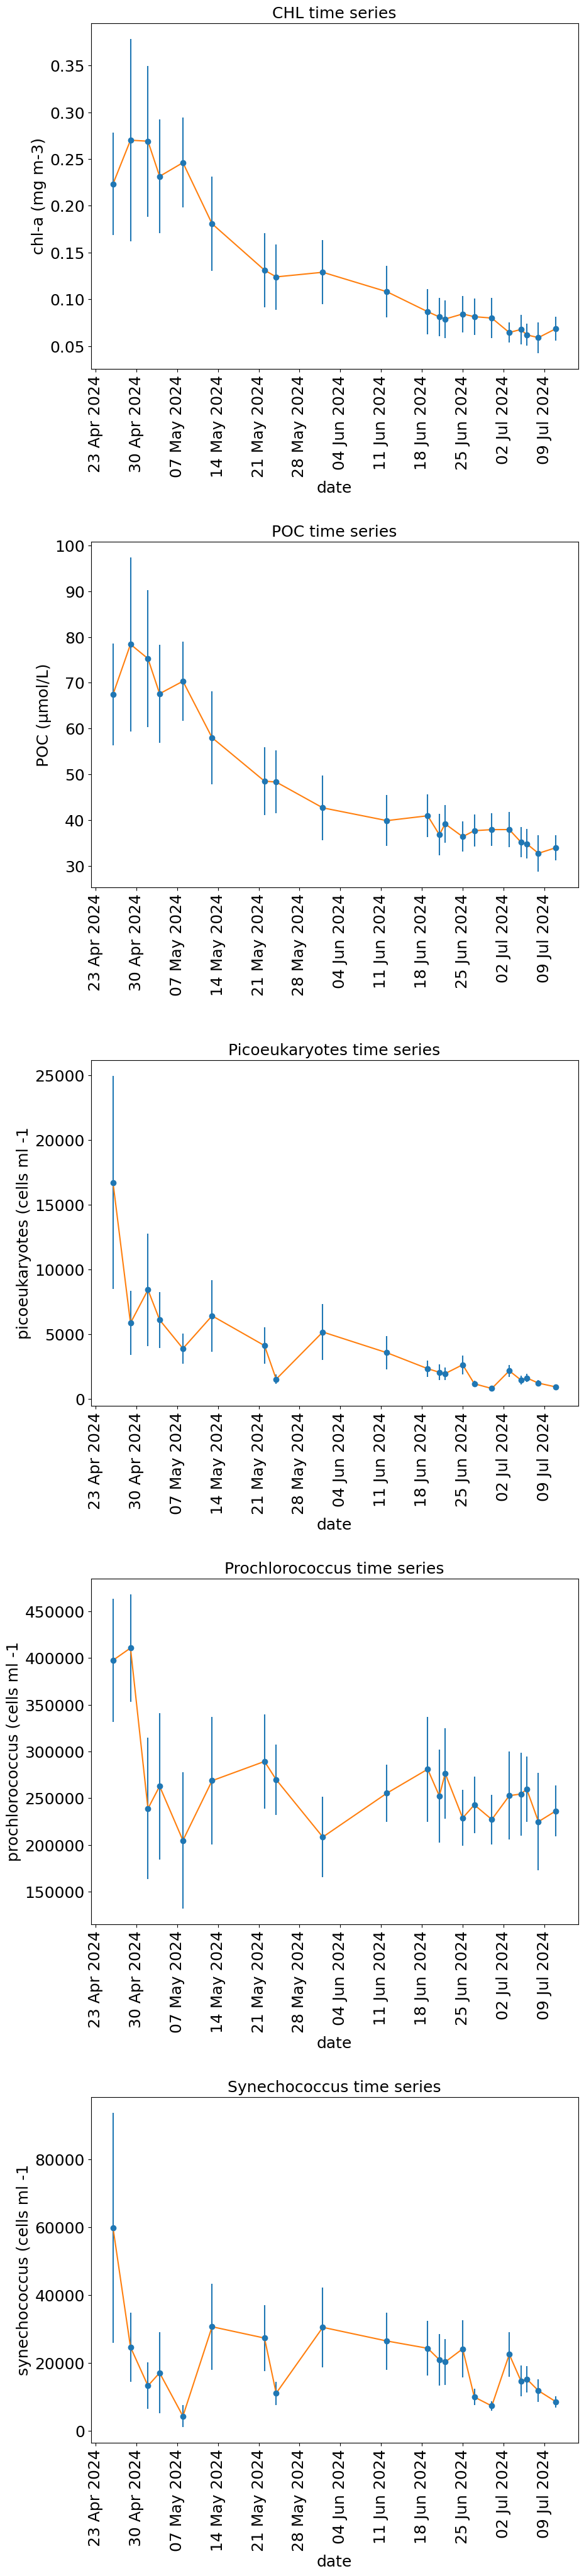

In [4]:
fig, (ax, ax2, ax3, ax4, ax5) = plt.subplots(5,1, figsize=(10,50))

# Plot for CHL
values=dat.chlmean.values
errors=dat.chlstd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
ax.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax.plot(df['date'], df['value'])
ax.set_xlabel('date')
ax.set_ylabel('chl-a (mg m-3)')
ax.set_title('CHL time series')
ax.tick_params(axis='x', rotation=90)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Set interval to 2 weeks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for POC
values=dat.pocmean.values
errors=dat.pocstd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
# Plot the time series with error bars
plt.xticks(rotation=90)
ax2.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax2.plot(df['date'], df['value'])
ax2.set_ylabel("date")
ax2.set_ylabel("POC (µmol/L)")
ax2.set_title('POC time series')
ax2.tick_params(axis='x', rotation=90)
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Picoeukaryotes
values=dat.picomean.values
errors=dat.picostd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
ax3.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax3.plot(df['date'], df['value'])
ax3.set_xlabel('date')
ax3.set_ylabel('picoeukaryotes (cells ml -1')
ax3.set_title('Picoeukaryotes time series')
ax3.tick_params(axis='x', rotation=90)
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Prochlorococcus
values=dat.promean.values
errors=dat.prostd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
ax4.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax4.plot(df['date'], df['value'])
ax4.set_xlabel('date')
ax4.set_ylabel('prochlorococcus (cells ml -1')
ax4.set_title('Prochlorococcus time series')
ax4.tick_params(axis='x', rotation=90)
ax4.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Synechococcus
values=dat.synmean.values
errors=dat.synstd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
ax5.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax5.plot(df['date'], df['value'])
ax5.set_xlabel('date')
ax5.set_ylabel('synechococcus (cells ml -1')
ax5.set_title('Synechococcus time series')
ax5.tick_params(axis='x', rotation=90)
ax5.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

plt.subplots_adjust(hspace=0.5)  # Increase the vertical space between subplots
plt.show()

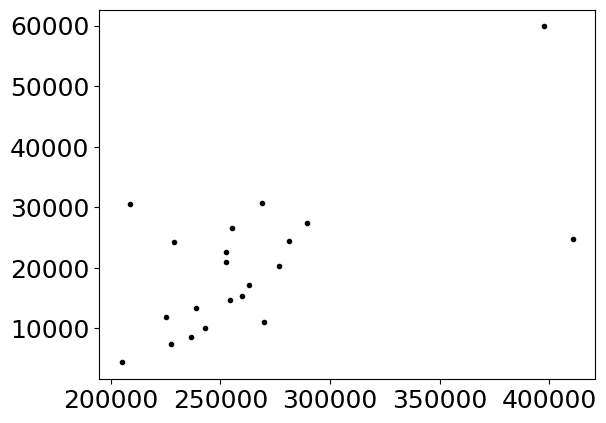

In [63]:
plt.plot(dat.promean,dat.synmean, "k.")

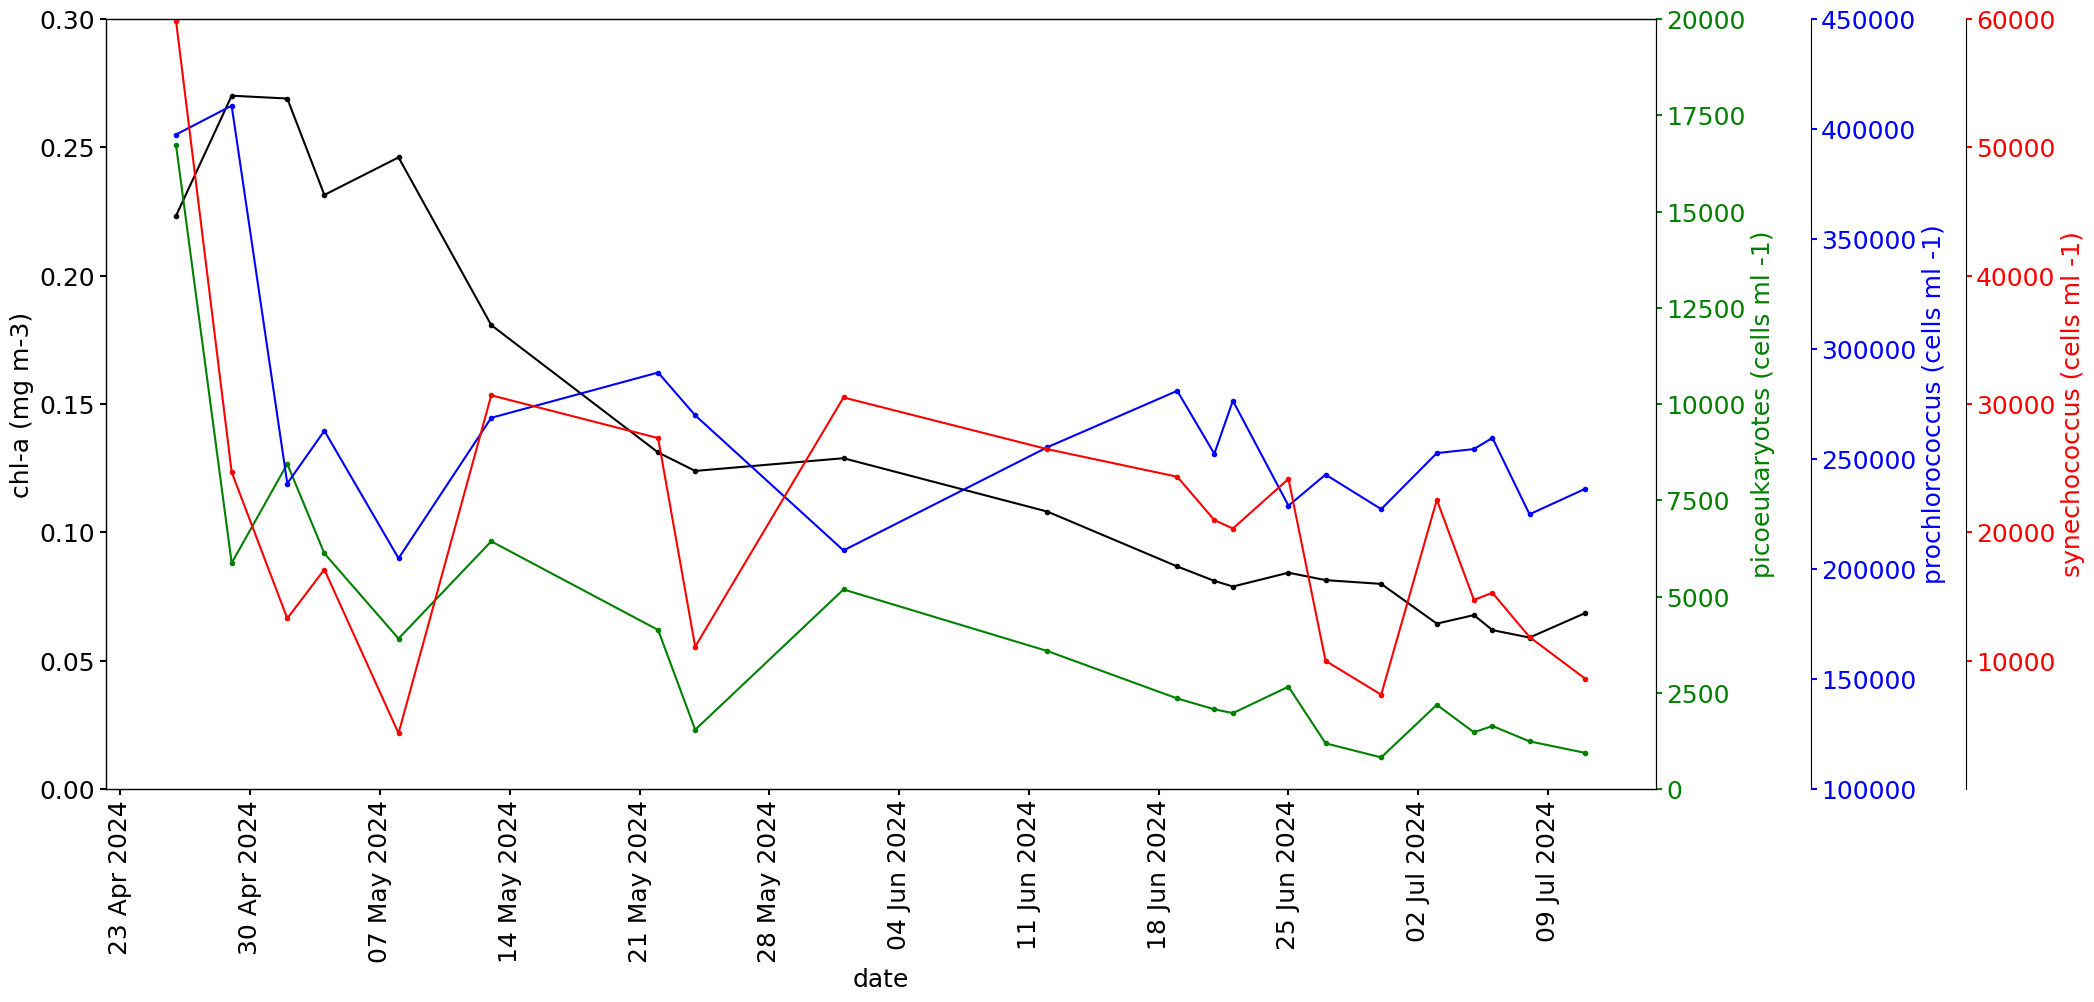

In [58]:
fig, ax = plt.subplots(figsize=(20,10))
# fig, (ax, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(20,5))

fig.subplots_adjust(right=0.9)

twin = ax.twinx()
twin1 = ax.twinx()
twin2 = ax.twinx()

# Offset the right spine of twin2.  The ticks and label have already been
# placed on the right by twinx above.
twin.spines.right.set_position(("axes", 1))
twin1.spines.right.set_position(("axes", 1.1))
twin2.spines.right.set_position(("axes", 1.2))

p, = ax.plot(datetimes,dat.chlmean, "k-", label="chl-a")
ax.plot(datetimes,dat.chlmean, "k.", label="chl-a")
p1, = twin.plot(datetimes,dat.picomean, "g-", label="picoeukaryotes")
twin.plot(datetimes,dat.picomean, "g.", label="picoeukaryotes")
p2, = twin1.plot(datetimes,dat.promean, "b-", label="prochlorococcus")
twin1.plot(datetimes,dat.promean, "b.", label="prochlorococcus")
p3, = twin2.plot(datetimes,dat.synmean, "r-", label="synechococcus")
twin2.plot(datetimes,dat.synmean, "r.", label="synechococcus")
# twin2.plot(alongtrack,median_filter(syn_grid[350,:],10), "r-", label="synechococcus")

# ax.set_xlim(0,400)
ax.set_ylim(0,0.3)
# twin.set_xlim(0,400)
twin.set_ylim(0,20000)
twin1.set_ylim(100000, 450000)
# twin1.set_xlim(0,400)
twin2.set_ylim(1, 60000)
# twin2.set_xlim(0,400)

ax.tick_params(axis='x', rotation=90)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

ax.set_xlabel("date")
ax.set_ylabel("chl-a (mg m-3)")
twin.set_ylabel("picoeukaryotes (cells ml -1)")
twin1.set_ylabel("prochlorococcus (cells ml -1)")
twin2.set_ylabel("synechococcus (cells ml -1)")

ax.yaxis.label.set_color(p.get_color())
twin.yaxis.label.set_color(p1.get_color())
twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', colors=p.get_color(), **tkw)
twin.tick_params(axis='y', colors=p1.get_color(), **tkw)
twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

# ax.legend(handles=[p, p1, p2, p3])

plt.show()

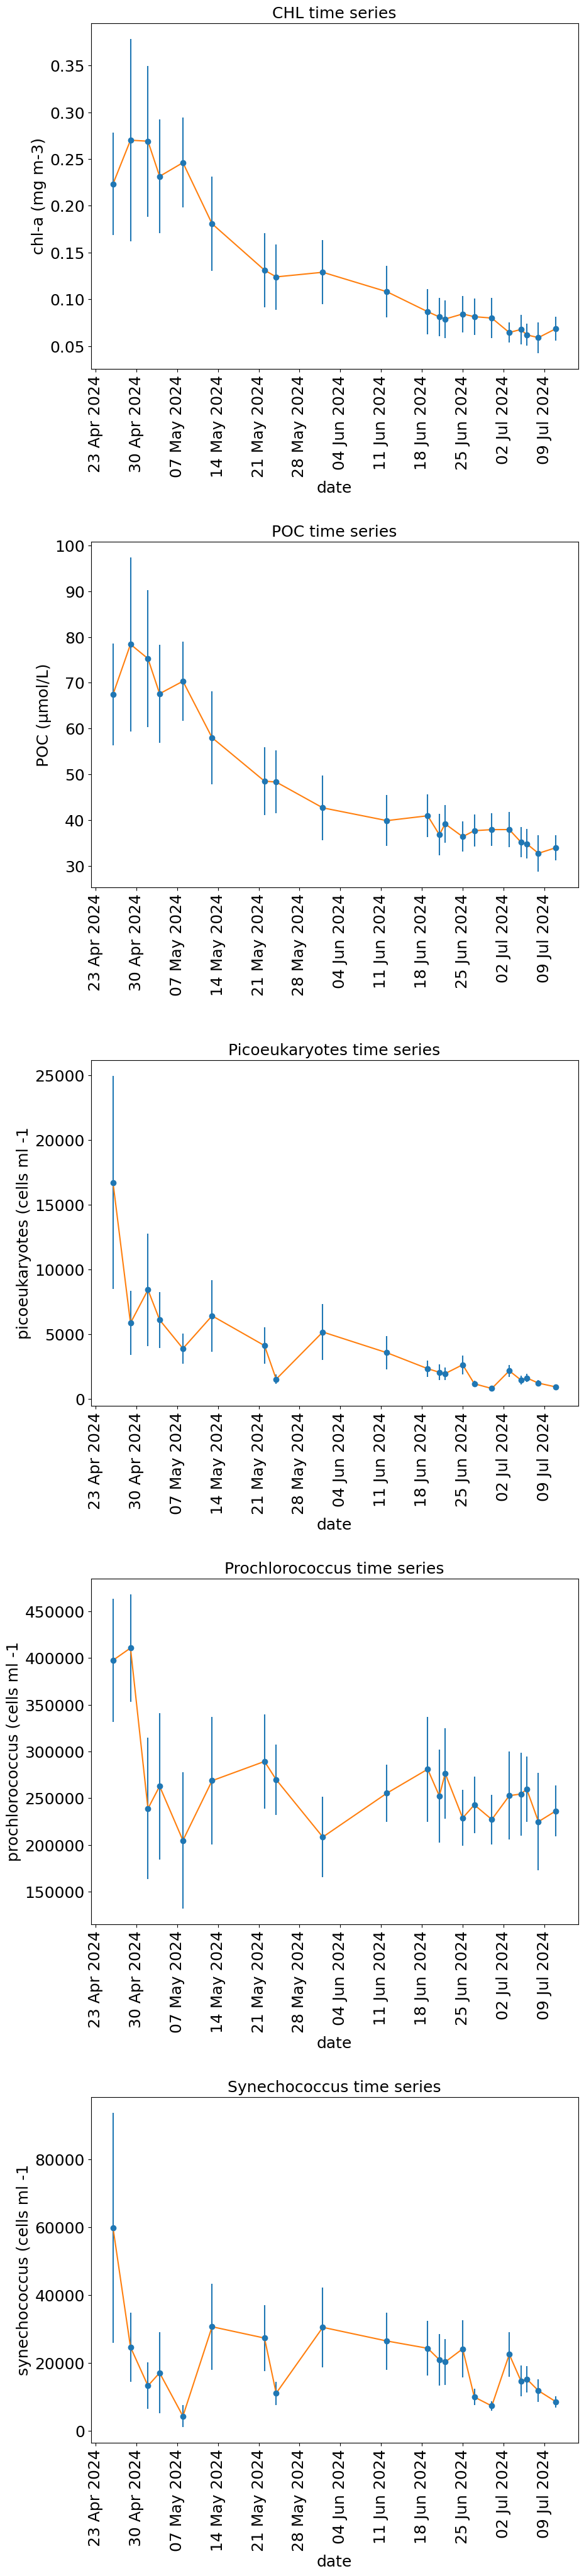

In [52]:
fig, (ax, ax2, ax3, ax4, ax5) = plt.subplots(5,1, figsize=(10,50))

# Plot for CHL
values=dat.chlmean.values
errors=dat.chlstd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
ax.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax.plot(df['date'], df['value'])
ax.set_xlabel('date')
ax.set_ylabel('chl-a (mg m-3)')
ax.set_title('CHL time series')
ax.tick_params(axis='x', rotation=90)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Set interval to 2 weeks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for POC
values=dat.pocmean.values
errors=dat.pocstd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
# Plot the time series with error bars
plt.xticks(rotation=90)
ax2.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax2.plot(df['date'], df['value'])
ax2.set_ylabel("date")
ax2.set_ylabel("POC (µmol/L)")
ax2.set_title('POC time series')
ax2.tick_params(axis='x', rotation=90)
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Picoeukaryotes
values=dat.picomean.values
errors=dat.picostd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
ax3.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax3.plot(df['date'], df['value'])
ax3.set_xlabel('date')
ax3.set_ylabel('picoeukaryotes (cells ml -1')
ax3.set_title('Picoeukaryotes time series')
ax3.tick_params(axis='x', rotation=90)
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Prochlorococcus
values=dat.promean.values
errors=dat.prostd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
plt.xticks(rotation=90)
ax4.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax4.plot(df['date'], df['value'])
ax4.set_xlabel('date')
ax4.set_ylabel('prochlorococcus (cells ml -1')
ax4.set_title('Prochlorococcus time series')
ax4.tick_params(axis='x', rotation=90)
ax4.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

# Plot for Synechococcus
values=dat.synmean.values
errors=dat.synstd.values
df = pd.DataFrame({'date': dates, 'value': values, 'error': errors})
df['date'] = pd.to_datetime(df['date'])  # Convert date column to datetime
ax5.errorbar(df['date'], df['value'], yerr=df['error'], fmt='o')
ax5.plot(df['date'], df['value'])
ax5.set_xlabel('date')
ax5.set_ylabel('synechococcus (cells ml -1')
ax5.set_title('Synechococcus time series')
ax5.tick_params(axis='x', rotation=90)
ax5.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Adjust frequency (e.g., monthly)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))  # Formatting the date (e.g., Jan 01, 2020)

plt.subplots_adjust(hspace=0.5)  # Increase the vertical space between subplots
plt.show()